In [3]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:
        for file in files[:5]:
            print(f"{indent}  {file}")

input/
  datasets/
    jesucristo/
      super-resolution-benchmarks/
        urban100/
          urban100/
        manga109/
          manga109/
        DIV2K/
          DIV2K_valid_HR/
          DIV2K_valid_LR_bicubic/
            Compressed_X4/
            X4/
        classic5/
          classic5/
        Set14/
          Set14/
            LRbicx3/
            GTmod12/
            LRbicx2/
            original/
            LRbicx4/
        LIVE1/
          LIVE1/
        T91/
          T91/
        Set5/
          Set5/
            LRbicx3/
            GTmod12/
            LRbicx2/
            original/
            LRbicx4/
        historical/
          historical/
            LR/
        General100/
          General100/
        RealSRSet5images/
          RealSRSet+5images/
        BSDS100/
          BSDS100/
        Kodak24/
          Kodak24/
        Set12/
          Set12/
        CBSD68/
          CBSD68/
        BSD68/
          BSD68/
        real_inputs/
        BSDS200/
 

In [5]:
from pathlib import Path
from PIL import Image

# =========================
# Dataset Paths
# =========================
DIV2K_ROOT = Path(
    "/kaggle/input/datasets/takihasan/div2k-dataset-for-super-resolution/Dataset"
)

TRAIN_HR_DIR = DIV2K_ROOT / "DIV2K_train_HR"
TRAIN_LR_DIR = DIV2K_ROOT / "DIV2K_train_LR_bicubic_X4" / "X4"

VALID_HR_DIR = DIV2K_ROOT / "DIV2K_valid_HR"
VALID_LR_DIR = DIV2K_ROOT / "DIV2K_valid_LR_bicubic_X4" / "X4"

for path in [TRAIN_HR_DIR, TRAIN_LR_DIR, VALID_HR_DIR, VALID_LR_DIR]:
    print(f"{path.name:30s} exists: {path.exists()} | path: {path}")


# =========================
# Pair Construction
# =========================
def build_div2k_pairs(hr_dir: Path, lr_dir: Path, scale: int = 4):
    hr_files = sorted(hr_dir.glob("*.png"))
    pairs = []

    for hr_path in hr_files:
        # HR: 0001.png -> LR: 0001x4.png
        lr_path = lr_dir / f"{hr_path.stem}x{scale}.png"

        if lr_path.exists():
            pairs.append((lr_path, hr_path))
        else:
            print(f"Missing LR pair for: {hr_path.name}")

    return pairs


train_pairs = build_div2k_pairs(TRAIN_HR_DIR, TRAIN_LR_DIR)
valid_pairs = build_div2k_pairs(VALID_HR_DIR, VALID_LR_DIR)

print("\nPair counts")
print(f"Training pairs   : {len(train_pairs)}")
print(f"Validation pairs : {len(valid_pairs)}")


# =========================
# Resolution Check
# =========================
def check_pair_resolution(pair, scale=4):
    lr_path, hr_path = pair
    lr = Image.open(lr_path)
    hr = Image.open(hr_path)

    expected_hr_size = (lr.width * scale, lr.height * scale)
    is_correct = hr.size == expected_hr_size

    print(f"LR image : {lr_path.name} | size = {lr.size}")
    print(f"HR image : {hr_path.name} | size = {hr.size}")
    print(f"Expected HR size from LR ×{scale}: {expected_hr_size}")
    print(f"Resolution pairing correct: {is_correct}")

    return is_correct


assert len(train_pairs) == 800, "Training pair count is not 800."
assert len(valid_pairs) == 100, "Validation pair count is not 100."
assert check_pair_resolution(train_pairs[0]), "Train HR-LR resolution mismatch."
assert check_pair_resolution(valid_pairs[0]), "Validation HR-LR resolution mismatch."

print("\nDIV2K ×4 dataset pairing is ready.")

DIV2K_train_HR                 exists: True | path: /kaggle/input/datasets/takihasan/div2k-dataset-for-super-resolution/Dataset/DIV2K_train_HR
X4                             exists: True | path: /kaggle/input/datasets/takihasan/div2k-dataset-for-super-resolution/Dataset/DIV2K_train_LR_bicubic_X4/X4
DIV2K_valid_HR                 exists: True | path: /kaggle/input/datasets/takihasan/div2k-dataset-for-super-resolution/Dataset/DIV2K_valid_HR
X4                             exists: True | path: /kaggle/input/datasets/takihasan/div2k-dataset-for-super-resolution/Dataset/DIV2K_valid_LR_bicubic_X4/X4

Pair counts
Training pairs   : 800
Validation pairs : 100
LR image : 0001x4.png | size = (510, 351)
HR image : 0001.png | size = (2040, 1404)
Expected HR size from LR ×4: (2040, 1404)
Resolution pairing correct: True
LR image : 0801x4.png | size = (510, 339)
HR image : 0801.png | size = (2040, 1356)
Expected HR size from LR ×4: (2040, 1356)
Resolution pairing correct: True

DIV2K ×4 dataset pairi

Sample LR: 0655x4.png | (510, 339)
Sample HR: 0655.png | (2040, 1356)


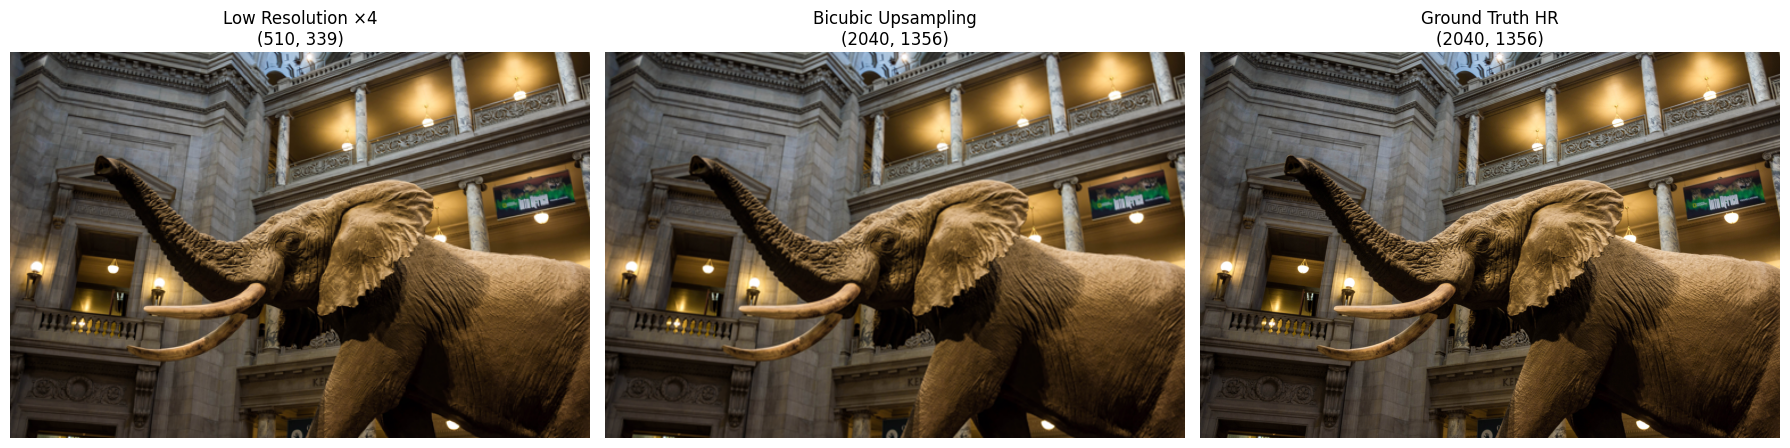

In [6]:
import random
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)

sample_lr_path, sample_hr_path = random.choice(train_pairs)

lr_img = Image.open(sample_lr_path).convert("RGB")
hr_img = Image.open(sample_hr_path).convert("RGB")

bicubic_img = lr_img.resize(
    hr_img.size,
    resample=Image.Resampling.BICUBIC
)

print(f"Sample LR: {sample_lr_path.name} | {lr_img.size}")
print(f"Sample HR: {sample_hr_path.name} | {hr_img.size}")

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(lr_img)
plt.title(f"Low Resolution ×4\n{lr_img.size}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(bicubic_img)
plt.title(f"Bicubic Upsampling\n{bicubic_img.size}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(hr_img)
plt.title(f"Ground Truth HR\n{hr_img.size}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
import numpy as np
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from tqdm.auto import tqdm

def rgb_to_y(img_np):
    """
    RGB image in [0, 255] -> Y channel used in standard SR evaluation.
    """
    img_np = img_np.astype(np.float32)
    y = (
        16.0
        + (65.481 * img_np[:, :, 0]
        + 128.553 * img_np[:, :, 1]
        + 24.966 * img_np[:, :, 2]) / 255.0
    )
    return y

def crop_border(img_np, border=4):
    if border == 0:
        return img_np
    return img_np[border:-border, border:-border]

bicubic_psnr_scores = []
bicubic_ssim_scores = []

for lr_path, hr_path in tqdm(valid_pairs, desc="Evaluating bicubic baseline"):
    lr = Image.open(lr_path).convert("RGB")
    hr = Image.open(hr_path).convert("RGB")

    bicubic = lr.resize(hr.size, Image.Resampling.BICUBIC)

    hr_np = np.array(hr)
    bicubic_np = np.array(bicubic)

    hr_y = crop_border(rgb_to_y(hr_np), border=4)
    bicubic_y = crop_border(rgb_to_y(bicubic_np), border=4)

    psnr = peak_signal_noise_ratio(
        hr_y,
        bicubic_y,
        data_range=255.0
    )

    ssim = structural_similarity(
        hr_y,
        bicubic_y,
        data_range=255.0
    )

    bicubic_psnr_scores.append(psnr)
    bicubic_ssim_scores.append(ssim)

print("\nBicubic ×4 Baseline on DIV2K Validation")
print(f"PSNR-Y: {np.mean(bicubic_psnr_scores):.4f} dB")
print(f"SSIM-Y: {np.mean(bicubic_ssim_scores):.4f}")

Evaluating bicubic baseline:   0%|          | 0/100 [00:00<?, ?it/s]


Bicubic ×4 Baseline on DIV2K Validation
PSNR-Y: 28.1028 dB
SSIM-Y: 0.7858


In [8]:
import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# =========================
# Utility Functions
# =========================
def pil_to_tensor(image):
    """
    PIL RGB image -> torch tensor in [0, 1], shape: C x H x W
    """
    image_np = np.array(image).astype(np.float32) / 255.0
    image_tensor = torch.from_numpy(image_np).permute(2, 0, 1).contiguous()
    return image_tensor


def augment_pair(lr_patch, hr_patch):
    """
    Apply identical augmentation operations to LR and HR patches.
    """
    if random.random() < 0.5:
        lr_patch = lr_patch.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
        hr_patch = hr_patch.transpose(Image.Transpose.FLIP_LEFT_RIGHT)

    if random.random() < 0.5:
        lr_patch = lr_patch.transpose(Image.Transpose.FLIP_TOP_BOTTOM)
        hr_patch = hr_patch.transpose(Image.Transpose.FLIP_TOP_BOTTOM)

    rotation_k = random.randint(0, 3)
    if rotation_k > 0:
        angle = 90 * rotation_k
        lr_patch = lr_patch.rotate(angle)
        hr_patch = hr_patch.rotate(angle)

    return lr_patch, hr_patch


# =========================
# Training Dataset
# =========================
class DIV2KTrainPatchDataset(Dataset):
    def __init__(self, pairs, lr_patch_size=64, scale=4, augment=True):
        self.pairs = pairs
        self.lr_patch_size = lr_patch_size
        self.scale = scale
        self.hr_patch_size = lr_patch_size * scale
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        lr_path, hr_path = self.pairs[index]

        lr_image = Image.open(lr_path).convert("RGB")
        hr_image = Image.open(hr_path).convert("RGB")

        # HR-LR scale consistency check
        assert hr_image.width == lr_image.width * self.scale
        assert hr_image.height == lr_image.height * self.scale

        # Random crop location in LR coordinate system
        max_x = lr_image.width - self.lr_patch_size
        max_y = lr_image.height - self.lr_patch_size

        x_lr = random.randint(0, max_x)
        y_lr = random.randint(0, max_y)

        # Corresponding coordinates in HR image
        x_hr = x_lr * self.scale
        y_hr = y_lr * self.scale

        lr_patch = lr_image.crop(
            (
                x_lr,
                y_lr,
                x_lr + self.lr_patch_size,
                y_lr + self.lr_patch_size
            )
        )

        hr_patch = hr_image.crop(
            (
                x_hr,
                y_hr,
                x_hr + self.hr_patch_size,
                y_hr + self.hr_patch_size
            )
        )

        if self.augment:
            lr_patch, hr_patch = augment_pair(lr_patch, hr_patch)

        return {
            "lr": pil_to_tensor(lr_patch),
            "hr": pil_to_tensor(hr_patch),
            "name": hr_path.stem
        }


# =========================
# Validation Dataset
# =========================
class DIV2KValidationDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        lr_path, hr_path = self.pairs[index]

        lr_image = Image.open(lr_path).convert("RGB")
        hr_image = Image.open(hr_path).convert("RGB")

        return {
            "lr": pil_to_tensor(lr_image),
            "hr": pil_to_tensor(hr_image),
            "name": hr_path.stem
        }

In [9]:
# =========================
# SwinIR-Light-Compatible Patch Size
# =========================
SCALE = 4
LR_PATCH_SIZE = 64
HR_PATCH_SIZE = LR_PATCH_SIZE * SCALE

train_dataset = DIV2KTrainPatchDataset(
    train_pairs,
    lr_patch_size=LR_PATCH_SIZE,
    scale=SCALE,
    augment=True
)

valid_dataset = DIV2KValidationDataset(valid_pairs)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

train_batch = next(iter(train_loader))

print("Updated SwinIR-Light training patch configuration")
print("LR patch size :", LR_PATCH_SIZE)
print("HR patch size :", HR_PATCH_SIZE)
print("LR batch shape:", train_batch["lr"].shape)
print("HR batch shape:", train_batch["hr"].shape)

assert train_batch["lr"].shape == (4, 3, 64, 64)
assert train_batch["hr"].shape == (4, 3, 256, 256)

print("\nPatch configuration is now compatible with SwinIR-Light.")

Updated SwinIR-Light training patch configuration
LR patch size : 64
HR patch size : 256
LR batch shape: torch.Size([4, 3, 64, 64])
HR batch shape: torch.Size([4, 3, 256, 256])

Patch configuration is now compatible with SwinIR-Light.


In [10]:
import os
import sys
from pathlib import Path

WORK_DIR = Path("/kaggle/working")
SWINIR_DIR = WORK_DIR / "SwinIR"

if not SWINIR_DIR.exists():
    !git clone -q https://github.com/JingyunLiang/SwinIR.git /kaggle/working/SwinIR
    print("Official SwinIR repository cloned.")
else:
    print("Official SwinIR repository already exists.")

sys.path.append(str(SWINIR_DIR))

from models.network_swinir import SwinIR

print("Official SwinIR model class imported successfully.")

Official SwinIR repository cloned.
Official SwinIR model class imported successfully.


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [11]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Official SwinIR-Light configuration for classical/lightweight ×4 SR
model = SwinIR(
    upscale=4,
    in_chans=3,
    img_size=64,
    window_size=8,
    img_range=1.0,
    depths=[6, 6, 6, 6],
    embed_dim=60,
    num_heads=[6, 6, 6, 6],
    mlp_ratio=2,
    upsampler="pixelshuffledirect",
    resi_connection="1conv"
).to(device)

num_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters    : {num_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Device: cuda
Total parameters    : 929,628
Trainable parameters: 929,628


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [12]:
model.eval()

lr_batch = train_batch["lr"].to(device)
hr_batch = train_batch["hr"].to(device)

with torch.no_grad():
    sr_batch = model(lr_batch)

print("Input LR shape :", lr_batch.shape)
print("Output SR shape:", sr_batch.shape)
print("Target HR shape:", hr_batch.shape)

assert sr_batch.shape == hr_batch.shape, "Model output and HR target dimensions do not match."
assert torch.isfinite(sr_batch).all(), "Model output contains NaN or Inf values."

print("\nSwinIR-Light ×4 forward pass is successful.")

Input LR shape : torch.Size([4, 3, 64, 64])
Output SR shape: torch.Size([4, 3, 256, 256])
Target HR shape: torch.Size([4, 3, 256, 256])

SwinIR-Light ×4 forward pass is successful.


In [13]:
import requests
from pathlib import Path
import torch

# =========================
# Official Pretrained SwinIR-Light ×4 Checkpoint
# =========================
MODEL_DIR = Path("/kaggle/working/model_zoo/swinir")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "002_lightweightSR_DIV2K_s64w8_SwinIR-S_x4.pth"
MODEL_PATH = MODEL_DIR / MODEL_NAME

MODEL_URL = (
    "https://github.com/JingyunLiang/SwinIR/"
    "releases/download/v0.0/"
    f"{MODEL_NAME}"
)

if not MODEL_PATH.exists():
    print("Downloading official pretrained SwinIR-Light ×4 checkpoint...")
    response = requests.get(MODEL_URL, timeout=120)
    response.raise_for_status()

    with open(MODEL_PATH, "wb") as f:
        f.write(response.content)

    print("Checkpoint downloaded.")
else:
    print("Checkpoint already exists.")

print("Checkpoint path:", MODEL_PATH)
print(f"Checkpoint size: {MODEL_PATH.stat().st_size / (1024**2):.2f} MB")


# =========================
# Load Weights into Existing SwinIR-Light Model
# =========================
checkpoint = torch.load(
    MODEL_PATH,
    map_location="cpu",
    weights_only=True
)

if isinstance(checkpoint, dict) and "params" in checkpoint:
    state_dict = checkpoint["params"]
else:
    state_dict = checkpoint

model.load_state_dict(state_dict, strict=True)
model = model.to(device)
model.eval()

print("\nOfficial pretrained SwinIR-Light ×4 weights loaded successfully.")

Checkpoint downloaded.
Checkpoint path: /kaggle/working/model_zoo/swinir/002_lightweightSR_DIV2K_s64w8_SwinIR-S_x4.pth
Checkpoint size: 16.43 MB

Official pretrained SwinIR-Light ×4 weights loaded successfully.


In [14]:
import torch

WINDOW_SIZE = 8
SCALE = 4

@torch.inference_mode()
def infer_swinir_full_image(model, lr_tensor, scale=4, window_size=8):
    """
    Full-image SwinIR inference following the official padding logic.

    Parameters
    ----------
    model : torch.nn.Module
        Pretrained SwinIR-Light model.
    lr_tensor : torch.Tensor
        LR input tensor with shape [1, 3, H, W], values in [0, 1].
    scale : int
        Super-resolution scale factor.
    window_size : int
        SwinIR attention window size.

    Returns
    -------
    torch.Tensor
        SR output cropped to the true HR spatial dimensions.
    """
    model.eval()

    _, _, h_old, w_old = lr_tensor.shape

    # Official SwinIR-style mirror padding to a valid window-size multiple
    h_pad = (h_old // window_size + 1) * window_size - h_old
    w_pad = (w_old // window_size + 1) * window_size - w_old

    lr_padded = torch.cat(
        [lr_tensor, torch.flip(lr_tensor, dims=[2])],
        dim=2
    )[:, :, :h_old + h_pad, :]

    lr_padded = torch.cat(
        [lr_padded, torch.flip(lr_padded, dims=[3])],
        dim=3
    )[:, :, :, :w_old + w_pad]

    sr_padded = model(lr_padded)

    # Remove padded output regions
    sr = sr_padded[:, :, :h_old * scale, :w_old * scale]

    return sr.clamp(0.0, 1.0)

In [15]:
import time

sample = valid_dataset[0]

lr_sample = sample["lr"].unsqueeze(0).to(device)
hr_sample = sample["hr"].unsqueeze(0).to(device)

torch.cuda.empty_cache()

start_time = time.time()
sr_sample = infer_swinir_full_image(
    model,
    lr_sample,
    scale=SCALE,
    window_size=WINDOW_SIZE
)
elapsed_time = time.time() - start_time

print("Image name     :", sample["name"])
print("LR shape       :", lr_sample.shape)
print("SR output shape:", sr_sample.shape)
print("HR target shape:", hr_sample.shape)
print(f"Inference time : {elapsed_time:.2f} seconds")

assert sr_sample.shape == hr_sample.shape
assert torch.isfinite(sr_sample).all()

print("\nPretrained SwinIR-Light full-image inference is successful.")

Image name     : 0801
LR shape       : torch.Size([1, 3, 339, 510])
SR output shape: torch.Size([1, 3, 1356, 2040])
HR target shape: torch.Size([1, 3, 1356, 2040])
Inference time : 3.44 seconds

Pretrained SwinIR-Light full-image inference is successful.


In [16]:
import numpy as np
from tqdm.auto import tqdm
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

def tensor_to_uint8_rgb(tensor):
    """
    Tensor [1, 3, H, W] in [0, 1] -> uint8 RGB image [H, W, 3].
    """
    image = tensor.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
    image = np.clip(image, 0.0, 1.0)
    image = np.round(image * 255.0).astype(np.uint8)
    return image


def rgb_to_y(img_np):
    """
    RGB uint8 image -> Y channel for SR evaluation.
    Same conversion used for our bicubic reference calculation.
    """
    img_np = img_np.astype(np.float32)

    y = (
        16.0
        + (
            65.481 * img_np[:, :, 0]
            + 128.553 * img_np[:, :, 1]
            + 24.966 * img_np[:, :, 2]
        ) / 255.0
    )

    return y


def crop_border(img_np, border=4):
    if border == 0:
        return img_np
    return img_np[border:-border, border:-border]


swinir_psnr_scores = []
swinir_ssim_scores = []

model.eval()
torch.cuda.empty_cache()

for sample in tqdm(valid_dataset, desc="Evaluating pretrained SwinIR-Light"):
    lr = sample["lr"].unsqueeze(0).to(device)
    hr = sample["hr"].unsqueeze(0)

    sr = infer_swinir_full_image(
        model,
        lr,
        scale=SCALE,
        window_size=WINDOW_SIZE
    )

    sr_np = tensor_to_uint8_rgb(sr)
    hr_np = tensor_to_uint8_rgb(hr)

    sr_y = crop_border(rgb_to_y(sr_np), border=SCALE)
    hr_y = crop_border(rgb_to_y(hr_np), border=SCALE)

    psnr = peak_signal_noise_ratio(
        hr_y,
        sr_y,
        data_range=255.0
    )

    ssim = structural_similarity(
        hr_y,
        sr_y,
        data_range=255.0
    )

    swinir_psnr_scores.append(psnr)
    swinir_ssim_scores.append(ssim)

print("\nOfficial Pretrained SwinIR-Light ×4 on DIV2K Validation")
print(f"PSNR-Y: {np.mean(swinir_psnr_scores):.4f} dB")
print(f"SSIM-Y: {np.mean(swinir_ssim_scores):.4f}")

print("\nComparison with Bicubic Baseline")
print(f"Bicubic PSNR-Y : {np.mean(bicubic_psnr_scores):.4f} dB")
print(f"SwinIR  PSNR-Y : {np.mean(swinir_psnr_scores):.4f} dB")
print(f"PSNR Improvement: {np.mean(swinir_psnr_scores) - np.mean(bicubic_psnr_scores):.4f} dB")

print(f"\nBicubic SSIM-Y : {np.mean(bicubic_ssim_scores):.4f}")
print(f"SwinIR  SSIM-Y : {np.mean(swinir_ssim_scores):.4f}")
print(f"SSIM Improvement: {np.mean(swinir_ssim_scores) - np.mean(bicubic_ssim_scores):.4f}")

Evaluating pretrained SwinIR-Light:   0%|          | 0/100 [00:00<?, ?it/s]


Official Pretrained SwinIR-Light ×4 on DIV2K Validation
PSNR-Y: 30.6509 dB
SSIM-Y: 0.8550

Comparison with Bicubic Baseline
Bicubic PSNR-Y : 28.1028 dB
SwinIR  PSNR-Y : 30.6509 dB
PSNR Improvement: 2.5481 dB

Bicubic SSIM-Y : 0.7858
SwinIR  SSIM-Y : 0.8550
SSIM Improvement: 0.0693


In [18]:
# ============================================================
# Final Custom Loss Definitions
# Hann-Windowed FFT Magnitude Loss + Laplacian Edge Loss
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


class FFTMagnitudeLoss(nn.Module):
    """
    Hann-windowed log-magnitude Fourier loss.

    A 2D Hann window is applied before FFT to reduce artificial
    high-frequency energy caused by random crop boundaries.
    """
    def __init__(self):
        super().__init__()

    def forward(self, sr, hr):
        # Compute FFT in float32 for numerical stability
        sr = sr.float()
        hr = hr.float()

        height, width = sr.shape[-2:]

        hann_y = torch.hann_window(
            height,
            periodic=False,
            device=sr.device,
            dtype=sr.dtype
        )

        hann_x = torch.hann_window(
            width,
            periodic=False,
            device=sr.device,
            dtype=sr.dtype
        )

        window_2d = torch.outer(hann_y, hann_x).view(1, 1, height, width)

        sr_windowed = sr * window_2d
        hr_windowed = hr * window_2d

        sr_fft = torch.fft.fft2(
            sr_windowed,
            dim=(-2, -1),
            norm="ortho"
        )

        hr_fft = torch.fft.fft2(
            hr_windowed,
            dim=(-2, -1),
            norm="ortho"
        )

        sr_log_magnitude = torch.log1p(torch.abs(sr_fft))
        hr_log_magnitude = torch.log1p(torch.abs(hr_fft))

        return F.l1_loss(sr_log_magnitude, hr_log_magnitude)


class LaplacianEdgeLoss(nn.Module):
    """
    Edge-preservation loss using a fixed Laplacian kernel.
    """
    def __init__(self):
        super().__init__()

        kernel = torch.tensor(
            [[0.0,  1.0, 0.0],
             [1.0, -4.0, 1.0],
             [0.0,  1.0, 0.0]],
            dtype=torch.float32
        )

        kernel = kernel.view(1, 1, 3, 3)
        self.register_buffer("kernel", kernel)

    def laplacian(self, image):
        channels = image.shape[1]
        kernel = self.kernel.repeat(channels, 1, 1, 1)

        return F.conv2d(
            image,
            kernel,
            padding=1,
            groups=channels
        )

    def forward(self, sr, hr):
        sr_edges = self.laplacian(sr.float())
        hr_edges = self.laplacian(hr.float())

        return F.l1_loss(sr_edges, hr_edges)


# Loss instances used in the actual experiments
l1_loss_fn = nn.L1Loss().to(device)
fft_loss_fn = FFTMagnitudeLoss().to(device)
edge_loss_fn = LaplacianEdgeLoss().to(device)

ALPHA = 0.10
BETA = 0.05

print("Final custom loss definitions are ready.")
print("FFT loss now uses a 2D Hann window before Fourier transformation.")
print(f"Current pilot alpha: {ALPHA}")
print(f"Current pilot beta : {BETA}")

Final custom loss definitions are ready.
FFT loss now uses a 2D Hann window before Fourier transformation.
Current pilot alpha: 0.1
Current pilot beta : 0.05


In [19]:
# ============================================================
# Controlled and Reproducible Training DataLoader
# ============================================================

import random
import numpy as np
import torch
from torch.utils.data import DataLoader

PILOT_SEED = 531


def set_experiment_seed(seed=PILOT_SEED):
    """
    Resets all random number generators before each experiment.
    This ensures that A0, A1, A2 and A3 begin with the same
    randomized training conditions.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def build_controlled_train_loader(seed=PILOT_SEED):
    """
    Creates a reproducible training DataLoader.

    num_workers=0 is intentionally used during controlled experiments
    because the Dataset performs random cropping and augmentation.
    This guarantees identical patch generation between experiments.
    """
    generator = torch.Generator()
    generator.manual_seed(seed)

    controlled_loader = DataLoader(
        train_dataset,
        batch_size=4,
        shuffle=True,
        num_workers=0,
        pin_memory=True,
        drop_last=True,
        generator=generator
    )

    return controlled_loader


# ============================================================
# Reproducibility Check
# ============================================================

set_experiment_seed(PILOT_SEED)
loader_run_1 = build_controlled_train_loader(PILOT_SEED)
batch_run_1 = next(iter(loader_run_1))

set_experiment_seed(PILOT_SEED)
loader_run_2 = build_controlled_train_loader(PILOT_SEED)
batch_run_2 = next(iter(loader_run_2))

print("First controlled batch names - Run 1:", list(batch_run_1["name"]))
print("First controlled batch names - Run 2:", list(batch_run_2["name"]))

same_names = list(batch_run_1["name"]) == list(batch_run_2["name"])
same_lr_patches = torch.equal(batch_run_1["lr"], batch_run_2["lr"])
same_hr_patches = torch.equal(batch_run_1["hr"], batch_run_2["hr"])

print("\nReproducibility checks")
print("Same image order :", same_names)
print("Same LR patches  :", same_lr_patches)
print("Same HR patches  :", same_hr_patches)

assert same_names, "Image ordering is not reproducible."
assert same_lr_patches, "LR random crops/augmentations are not reproducible."
assert same_hr_patches, "HR random crops/augmentations are not reproducible."

print("\nControlled DataLoader check passed.")

First controlled batch names - Run 1: ['0461', '0121', '0459', '0277']
First controlled batch names - Run 2: ['0461', '0121', '0459', '0277']

Reproducibility checks
Same image order : True
Same LR patches  : True
Same HR patches  : True

Controlled DataLoader check passed.


In [20]:
# ============================================================
# Fresh Model Factory and Quick Pilot Evaluation Metrics
# ============================================================

import gc
import numpy as np
import torch
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# Ten evenly distributed DIV2K validation samples.
# These are used only for pilot monitoring, not final reported results.
QUICK_VAL_INDICES = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]

# Frequencies with normalized radius >= 0.50 are treated as high-frequency.
HF_CUTOFF = 0.50


def build_fresh_pretrained_swinir():
    """
    Creates a fresh SwinIR-Light model initialized from the same
    official pretrained checkpoint for every experiment.
    """
    fresh_model = SwinIR(
        upscale=4,
        in_chans=3,
        img_size=64,
        window_size=8,
        img_range=1.0,
        depths=[6, 6, 6, 6],
        embed_dim=60,
        num_heads=[6, 6, 6, 6],
        mlp_ratio=2,
        upsampler="pixelshuffledirect",
        resi_connection="1conv"
    )

    checkpoint = torch.load(
        MODEL_PATH,
        map_location="cpu",
        weights_only=True
    )

    if isinstance(checkpoint, dict) and "params" in checkpoint:
        state_dict = checkpoint["params"]
    else:
        state_dict = checkpoint

    fresh_model.load_state_dict(state_dict, strict=True)
    return fresh_model.to(device)


def tensor_rgb_to_luma(image_tensor):
    """
    RGB tensor in [0, 1], shape [B, 3, H, W] -> luminance tensor [B, 1, H, W].
    Used only for the custom frequency-domain metric.
    """
    return (
        0.299 * image_tensor[:, 0:1, :, :]
        + 0.587 * image_tensor[:, 1:2, :, :]
        + 0.114 * image_tensor[:, 2:3, :, :]
    )


@torch.inference_mode()
def compute_hf_lse(sr, hr, border=4, cutoff=HF_CUTOFF):
    """
    High-Frequency Log-Spectrum Error.

    Lower is better.

    Steps:
    1. Convert SR and HR to luminance.
    2. Remove scale-border pixels.
    3. Apply a 2D Hann window to reduce boundary artifacts.
    4. Compute log FFT-magnitude spectra.
    5. Average absolute spectral error only in the high-frequency region.
    """
    sr_y = tensor_rgb_to_luma(sr.float())
    hr_y = tensor_rgb_to_luma(hr.float())

    if border > 0:
        sr_y = sr_y[:, :, border:-border, border:-border]
        hr_y = hr_y[:, :, border:-border, border:-border]

    height, width = sr_y.shape[-2:]

    hann_y = torch.hann_window(
        height,
        periodic=False,
        dtype=sr_y.dtype,
        device=sr_y.device
    )

    hann_x = torch.hann_window(
        width,
        periodic=False,
        dtype=sr_y.dtype,
        device=sr_y.device
    )

    window_2d = torch.outer(hann_y, hann_x).view(1, 1, height, width)

    sr_fft = torch.fft.fftshift(
        torch.fft.fft2(sr_y * window_2d, dim=(-2, -1), norm="ortho"),
        dim=(-2, -1)
    )

    hr_fft = torch.fft.fftshift(
        torch.fft.fft2(hr_y * window_2d, dim=(-2, -1), norm="ortho"),
        dim=(-2, -1)
    )

    sr_log_magnitude = torch.log1p(torch.abs(sr_fft))
    hr_log_magnitude = torch.log1p(torch.abs(hr_fft))

    freq_y = torch.linspace(-1.0, 1.0, height, device=sr_y.device)
    freq_x = torch.linspace(-1.0, 1.0, width, device=sr_y.device)

    grid_y, grid_x = torch.meshgrid(
        freq_y,
        freq_x,
        indexing="ij"
    )

    radius = torch.sqrt(grid_x ** 2 + grid_y ** 2)
    high_frequency_mask = (radius >= cutoff).view(1, 1, height, width)

    spectral_error = torch.abs(sr_log_magnitude - hr_log_magnitude)

    return spectral_error[high_frequency_mask].mean().item()


@torch.inference_mode()
def evaluate_quick_subset(eval_model, dataset, indices):
    """
    Pilot monitoring evaluation on a fixed 10-image subset.

    Returns:
    - PSNR-Y: higher is better
    - SSIM-Y: higher is better
    - HF-LSE: lower is better
    """
    eval_model.eval()

    psnr_scores = []
    ssim_scores = []
    hf_lse_scores = []

    for index in indices:
        sample = dataset[index]

        lr = sample["lr"].unsqueeze(0).to(device)
        hr = sample["hr"].unsqueeze(0).to(device)

        sr = infer_swinir_full_image(
            eval_model,
            lr,
            scale=SCALE,
            window_size=WINDOW_SIZE
        )

        sr_np = tensor_to_uint8_rgb(sr)
        hr_np = tensor_to_uint8_rgb(hr)

        sr_y = crop_border(rgb_to_y(sr_np), border=SCALE)
        hr_y = crop_border(rgb_to_y(hr_np), border=SCALE)

        psnr_scores.append(
            peak_signal_noise_ratio(hr_y, sr_y, data_range=255.0)
        )

        ssim_scores.append(
            structural_similarity(hr_y, sr_y, data_range=255.0)
        )

        hf_lse_scores.append(
            compute_hf_lse(sr, hr, border=SCALE, cutoff=HF_CUTOFF)
        )

    return {
        "psnr_y": float(np.mean(psnr_scores)),
        "ssim_y": float(np.mean(ssim_scores)),
        "hf_lse": float(np.mean(hf_lse_scores))
    }


# ============================================================
# Official Pretrained Reference on the Pilot Subset
# ============================================================

quick_reference_model = build_fresh_pretrained_swinir()

quick_reference_metrics = evaluate_quick_subset(
    quick_reference_model,
    valid_dataset,
    QUICK_VAL_INDICES
)

print("Quick-monitoring reference for official pretrained SwinIR-Light")
print(f"Validation indices: {QUICK_VAL_INDICES}")
print(f"PSNR-Y : {quick_reference_metrics['psnr_y']:.4f} dB")
print(f"SSIM-Y : {quick_reference_metrics['ssim_y']:.4f}")
print(f"HF-LSE : {quick_reference_metrics['hf_lse']:.8f}  (lower is better)")

del quick_reference_model
torch.cuda.empty_cache()
gc.collect()

Quick-monitoring reference for official pretrained SwinIR-Light
Validation indices: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
PSNR-Y : 30.2209 dB
SSIM-Y : 0.8770
HF-LSE : 0.00715494  (lower is better)


8

In [22]:
# ============================================================
# Sanity Check for Final Windowed FFT Loss
# ============================================================

sanity_model = build_fresh_pretrained_swinir()
sanity_model.train()

lr_check = batch_run_1["lr"].to(device)
hr_check = batch_run_1["hr"].to(device)

sanity_model.zero_grad(set_to_none=True)

sr_check = sanity_model(lr_check)

loss_l1 = l1_loss_fn(sr_check, hr_check)
loss_fft = fft_loss_fn(sr_check, hr_check)
loss_edge = edge_loss_fn(sr_check, hr_check)

weighted_fft = ALPHA * loss_fft
weighted_edge = BETA * loss_edge
loss_a3 = loss_l1 + weighted_fft + weighted_edge

print("Loss values with Hann-windowed FFT supervision")
print(f"L1 loss       : {loss_l1.item():.6f}")
print(f"FFT loss      : {loss_fft.item():.6f}")
print(f"Edge loss     : {loss_edge.item():.6f}")

print("\nWeighted contributions")
print(f"alpha * FFT    : {weighted_fft.item():.6f}")
print(f"beta  * Edge   : {weighted_edge.item():.6f}")
print(f"FFT / L1 ratio : {(weighted_fft / loss_l1).item() * 100:.2f}%")
print(f"Edge / L1 ratio: {(weighted_edge / loss_l1).item() * 100:.2f}%")

loss_a3.backward()

gradient_norms = [
    parameter.grad.detach().norm().item()
    for parameter in sanity_model.parameters()
    if parameter.grad is not None
]

total_grad_norm = sum(gradient_norms)

print("\nBackward check")
print(f"Parameters with gradients: {len(gradient_norms)}")
print(f"Sum of gradient norms    : {total_grad_norm:.6f}")

assert torch.isfinite(loss_l1)
assert torch.isfinite(loss_fft)
assert torch.isfinite(loss_edge)
assert len(gradient_norms) > 0
assert total_grad_norm > 0

del sanity_model
torch.cuda.empty_cache()

print("\nWindowed FFT loss sanity check passed.")

Loss values with Hann-windowed FFT supervision
L1 loss       : 0.010376
FFT loss      : 0.002425
Edge loss     : 0.026848

Weighted contributions
alpha * FFT    : 0.000242
beta  * Edge   : 0.001342
FFT / L1 ratio : 2.34%
Edge / L1 ratio: 12.94%

Backward check
Parameters with gradients: 330
Sum of gradient norms    : 0.126616

Windowed FFT loss sanity check passed.


In [23]:
# ============================================================
# Auxiliary-Loss Weight Calibration for Pilot Experiments
# ============================================================

import pandas as pd
import torch

# Use exactly the same controlled batch already verified earlier.
lr_calibration = batch_run_1["lr"].to(device)
hr_calibration = batch_run_1["hr"].to(device)

calibration_model = build_fresh_pretrained_swinir()
calibration_model.eval()  # deterministic forward; gradients are still enabled


def measure_component_gradient_norm(model, component_name):
    """
    Measures the global gradient L2 norm produced by one loss component.
    No optimizer step is applied.
    """
    model.zero_grad(set_to_none=True)

    sr = model(lr_calibration)

    if component_name == "L1":
        loss = l1_loss_fn(sr, hr_calibration)
    elif component_name == "FFT":
        loss = fft_loss_fn(sr, hr_calibration)
    elif component_name == "Edge":
        loss = edge_loss_fn(sr, hr_calibration)
    else:
        raise ValueError(f"Unknown component: {component_name}")

    loss.backward()

    squared_norm_sum = torch.zeros((), device=device)

    for parameter in model.parameters():
        if parameter.grad is not None:
            squared_norm_sum += parameter.grad.detach().pow(2).sum()

    gradient_norm = torch.sqrt(squared_norm_sum).item()

    return loss.item(), gradient_norm


l1_value, l1_grad_norm = measure_component_gradient_norm(
    calibration_model, "L1"
)

fft_value, fft_grad_norm = measure_component_gradient_norm(
    calibration_model, "FFT"
)

edge_value, edge_grad_norm = measure_component_gradient_norm(
    calibration_model, "Edge"
)

raw_stats = pd.DataFrame([
    {
        "component": "L1",
        "raw_loss": l1_value,
        "raw_gradient_norm": l1_grad_norm
    },
    {
        "component": "FFT",
        "raw_loss": fft_value,
        "raw_gradient_norm": fft_grad_norm
    },
    {
        "component": "Edge",
        "raw_loss": edge_value,
        "raw_gradient_norm": edge_grad_norm
    }
])

print("Raw component statistics")
display(raw_stats)


# Candidate FFT weights for A1
alpha_candidates = [0.05, 0.10, 0.20, 0.50, 1.00]

alpha_rows = []

for alpha in alpha_candidates:
    alpha_rows.append({
        "alpha": alpha,
        "weighted_fft_loss": alpha * fft_value,
        "weighted_fft_loss_vs_l1_percent": 100 * alpha * fft_value / l1_value,
        "weighted_fft_grad_vs_l1_percent": 100 * alpha * fft_grad_norm / l1_grad_norm
    })

alpha_table = pd.DataFrame(alpha_rows)

print("\nFFT alpha candidate analysis")
display(alpha_table)


# Candidate Edge weights for later A2/A3 experiments
beta_candidates = [0.01, 0.02, 0.05, 0.10]

beta_rows = []

for beta in beta_candidates:
    beta_rows.append({
        "beta": beta,
        "weighted_edge_loss": beta * edge_value,
        "weighted_edge_loss_vs_l1_percent": 100 * beta * edge_value / l1_value,
        "weighted_edge_grad_vs_l1_percent": 100 * beta * edge_grad_norm / l1_grad_norm
    })

beta_table = pd.DataFrame(beta_rows)

print("\nEdge beta candidate analysis")
display(beta_table)

calibration_model.zero_grad(set_to_none=True)
del calibration_model
torch.cuda.empty_cache()

print("\nTemporary auxiliary-loss calibration completed.")

Raw component statistics


,component,raw_loss,raw_gradient_norm
0,L1,0.010303,0.016939
1,FFT,0.002432,0.013359
2,Edge,0.026719,0.026649



FFT alpha candidate analysis


,alpha,weighted_fft_loss,weighted_fft_loss_vs_l1_percent,weighted_fft_grad_vs_l1_percent
0,0.05,0.000122,1.180204,3.943157
1,0.10,0.000243,2.360408,7.886313
2,0.20,0.000486,4.720817,15.772627
3,0.50,0.001216,11.802042,39.431567
4,1.00,0.002432,23.604084,78.863133



Edge beta candidate analysis


,beta,weighted_edge_loss,weighted_edge_loss_vs_l1_percent,weighted_edge_grad_vs_l1_percent
0,0.01,0.000267,2.593281,1.573211
1,0.02,0.000534,5.186562,3.146422
2,0.05,0.001336,12.966404,7.866055
3,0.10,0.002672,25.932808,15.732110



Temporary auxiliary-loss calibration completed.


In [24]:
# ============================================================
# Controlled Pilot Fine-Tuning with PSNR, SSIM and HF-LSE
# ============================================================

import gc
import time
import pandas as pd
from pathlib import Path

WINDOWED_PILOT_DIR = Path("/kaggle/working/fa_srnet_windowed_fft_pilot")
WINDOWED_PILOT_DIR.mkdir(parents=True, exist_ok=True)

PILOT_ITERS = 200
EVAL_EVERY = 100
LEARNING_RATE = 2e-5

assert ALPHA == 0.10, "ALPHA must be set to 0.10 before running the new pilot."
assert BETA == 0.05, "BETA must remain 0.05 for the planned experiments."


def train_controlled_pilot_experiment(
    experiment_name,
    alpha=0.0,
    beta=0.0,
    num_iterations=PILOT_ITERS,
    learning_rate=LEARNING_RATE,
    eval_every=EVAL_EVERY,
    seed=PILOT_SEED
):
    """
    Controlled fine-tuning experiment.

    Every experiment starts from:
    - the same official pretrained SwinIR-Light checkpoint,
    - the same seed,
    - the same shuffled training order,
    - the same random crops and augmentations.

    Pilot monitoring metrics:
    - PSNR-Y: higher is better
    - SSIM-Y: higher is better
    - HF-LSE: lower is better
    """

    print("=" * 74)
    print(f"Starting controlled experiment: {experiment_name}")
    print(f"FFT weight alpha : {alpha}")
    print(f"Edge weight beta : {beta}")
    print(f"Iterations       : {num_iterations}")
    print(f"Learning rate    : {learning_rate}")
    print(f"Seed             : {seed}")
    print("=" * 74)

    experiment_dir = WINDOWED_PILOT_DIR / experiment_name
    experiment_dir.mkdir(parents=True, exist_ok=True)

    # Ensure identical patch stream and identical initialization.
    set_experiment_seed(seed)
    controlled_train_loader = build_controlled_train_loader(seed)

    experiment_model = build_fresh_pretrained_swinir()
    experiment_model.train()

    optimizer = torch.optim.Adam(
        experiment_model.parameters(),
        lr=learning_rate,
        betas=(0.9, 0.999)
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=num_iterations,
        eta_min=learning_rate * 0.1
    )

    amp_enabled = device.type == "cuda"
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=amp_enabled
    )

    history = []
    train_iterator = iter(controlled_train_loader)

    # Evaluation before any fine-tuning.
    initial_metrics = evaluate_quick_subset(
        experiment_model,
        valid_dataset,
        QUICK_VAL_INDICES
    )

    history.append({
        "experiment": experiment_name,
        "iteration": 0,
        "learning_rate": learning_rate,
        "loss_total": np.nan,
        "loss_l1": np.nan,
        "loss_fft": np.nan,
        "loss_edge": np.nan,
        "quick_psnr_y": initial_metrics["psnr_y"],
        "quick_ssim_y": initial_metrics["ssim_y"],
        "quick_hf_lse": initial_metrics["hf_lse"]
    })

    print(
        f"Initial quick validation | "
        f"PSNR-Y: {initial_metrics['psnr_y']:.4f} dB | "
        f"SSIM-Y: {initial_metrics['ssim_y']:.4f} | "
        f"HF-LSE: {initial_metrics['hf_lse']:.8f}"
    )

    experiment_model.train()
    start_time = time.time()

    for iteration in range(1, num_iterations + 1):
        try:
            batch = next(train_iterator)
        except StopIteration:
            train_iterator = iter(controlled_train_loader)
            batch = next(train_iterator)

        lr = batch["lr"].to(device, non_blocking=True)
        hr = batch["hr"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type=device.type,
            enabled=amp_enabled
        ):
            sr = experiment_model(lr)

            loss_l1 = l1_loss_fn(sr, hr)

            if alpha > 0:
                loss_fft = fft_loss_fn(sr, hr)
            else:
                loss_fft = torch.zeros((), device=device)

            if beta > 0:
                loss_edge = edge_loss_fn(sr, hr)
            else:
                loss_edge = torch.zeros((), device=device)

            total_loss = (
                loss_l1
                + alpha * loss_fft
                + beta * loss_edge
            )

        scaler.scale(total_loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]

        row = {
            "experiment": experiment_name,
            "iteration": iteration,
            "learning_rate": current_lr,
            "loss_total": float(total_loss.detach().cpu()),
            "loss_l1": float(loss_l1.detach().cpu()),
            "loss_fft": float(loss_fft.detach().cpu()),
            "loss_edge": float(loss_edge.detach().cpu()),
            "quick_psnr_y": np.nan,
            "quick_ssim_y": np.nan,
            "quick_hf_lse": np.nan
        }

        if iteration == 1 or iteration % 25 == 0:
            print(
                f"[{experiment_name}] Iter {iteration:4d}/{num_iterations} | "
                f"Total: {row['loss_total']:.6f} | "
                f"L1: {row['loss_l1']:.6f} | "
                f"FFT: {row['loss_fft']:.6f} | "
                f"Edge: {row['loss_edge']:.6f} | "
                f"LR: {current_lr:.2e}"
            )

        if iteration % eval_every == 0 or iteration == num_iterations:
            quick_metrics = evaluate_quick_subset(
                experiment_model,
                valid_dataset,
                QUICK_VAL_INDICES
            )

            row["quick_psnr_y"] = quick_metrics["psnr_y"]
            row["quick_ssim_y"] = quick_metrics["ssim_y"]
            row["quick_hf_lse"] = quick_metrics["hf_lse"]

            print(
                f"  Quick validation at iter {iteration} | "
                f"PSNR-Y: {quick_metrics['psnr_y']:.4f} dB | "
                f"SSIM-Y: {quick_metrics['ssim_y']:.4f} | "
                f"HF-LSE: {quick_metrics['hf_lse']:.8f}"
            )

            experiment_model.train()

        history.append(row)

    runtime_minutes = (time.time() - start_time) / 60.0
    history_df = pd.DataFrame(history)

    checkpoint_path = experiment_dir / f"{experiment_name}_final.pth"
    log_path = experiment_dir / f"{experiment_name}_history.csv"

    torch.save(
        {
            "experiment": experiment_name,
            "model_state_dict": experiment_model.state_dict(),
            "alpha": alpha,
            "beta": beta,
            "iterations": num_iterations,
            "learning_rate": learning_rate,
            "seed": seed,
            "hf_cutoff": HF_CUTOFF,
            "quick_val_indices": QUICK_VAL_INDICES
        },
        checkpoint_path
    )

    history_df.to_csv(log_path, index=False)

    final_metrics_row = history_df.dropna(subset=["quick_psnr_y"]).iloc[-1]

    result = {
        "experiment": experiment_name,
        "alpha": alpha,
        "beta": beta,
        "iterations": num_iterations,
        "initial_quick_psnr_y": initial_metrics["psnr_y"],
        "final_quick_psnr_y": float(final_metrics_row["quick_psnr_y"]),
        "delta_psnr_y": float(
            final_metrics_row["quick_psnr_y"] - initial_metrics["psnr_y"]
        ),
        "initial_quick_ssim_y": initial_metrics["ssim_y"],
        "final_quick_ssim_y": float(final_metrics_row["quick_ssim_y"]),
        "delta_ssim_y": float(
            final_metrics_row["quick_ssim_y"] - initial_metrics["ssim_y"]
        ),
        "initial_quick_hf_lse": initial_metrics["hf_lse"],
        "final_quick_hf_lse": float(final_metrics_row["quick_hf_lse"]),
        "delta_hf_lse": float(
            final_metrics_row["quick_hf_lse"] - initial_metrics["hf_lse"]
        ),
        "final_train_l1": float(history_df.iloc[-1]["loss_l1"]),
        "final_train_fft": float(history_df.iloc[-1]["loss_fft"]),
        "final_train_edge": float(history_df.iloc[-1]["loss_edge"]),
        "runtime_minutes": runtime_minutes,
        "checkpoint_path": str(checkpoint_path),
        "log_path": str(log_path)
    }

    print("\nControlled experiment completed:", experiment_name)
    print(f"Runtime       : {runtime_minutes:.2f} minutes")
    print(f"PSNR-Y change : {result['delta_psnr_y']:+.4f} dB")
    print(f"SSIM-Y change : {result['delta_ssim_y']:+.6f}")
    print(f"HF-LSE change : {result['delta_hf_lse']:+.8f}  (negative is better)")
    print(f"Checkpoint    : {checkpoint_path}")
    print(f"Log           : {log_path}")

    del experiment_model
    torch.cuda.empty_cache()
    gc.collect()

    return result, history_df


print("HF-LSE-aware controlled pilot training function is ready.")

HF-LSE-aware controlled pilot training function is ready.


In [25]:
# ============================================================
# Windowed-FFT Pilot Experiments: A0 versus A1
# ============================================================

a0_result, a0_history = train_controlled_pilot_experiment(
    experiment_name="A0_L1",
    alpha=0.0,
    beta=0.0
)

a1_result, a1_history = train_controlled_pilot_experiment(
    experiment_name="A1_L1_WindowedFFT",
    alpha=ALPHA,
    beta=0.0
)

pilot_comparison = pd.DataFrame([
    a0_result,
    a1_result
])

comparison_columns = [
    "experiment",
    "alpha",
    "beta",
    "initial_quick_psnr_y",
    "final_quick_psnr_y",
    "delta_psnr_y",
    "initial_quick_ssim_y",
    "final_quick_ssim_y",
    "delta_ssim_y",
    "initial_quick_hf_lse",
    "final_quick_hf_lse",
    "delta_hf_lse",
    "final_train_l1",
    "final_train_fft",
    "runtime_minutes"
]

display(pilot_comparison[comparison_columns])

comparison_path = WINDOWED_PILOT_DIR / "A0_A1_windowed_fft_pilot_comparison.csv"
pilot_comparison[comparison_columns].to_csv(comparison_path, index=False)

print(f"\nComparison table saved to: {comparison_path}")

Starting controlled experiment: A0_L1
FFT weight alpha : 0.0
Edge weight beta : 0.0
Iterations       : 200
Learning rate    : 2e-05
Seed             : 531
Initial quick validation | PSNR-Y: 30.2209 dB | SSIM-Y: 0.8770 | HF-LSE: 0.00715494
[A0_L1] Iter    1/200 | Total: 0.010347 | L1: 0.010347 | FFT: 0.000000 | Edge: 0.000000 | LR: 2.00e-05
[A0_L1] Iter   25/200 | Total: 0.023821 | L1: 0.023821 | FFT: 0.000000 | Edge: 0.000000 | LR: 1.93e-05
[A0_L1] Iter   50/200 | Total: 0.014320 | L1: 0.014320 | FFT: 0.000000 | Edge: 0.000000 | LR: 1.74e-05
[A0_L1] Iter   75/200 | Total: 0.016545 | L1: 0.016545 | FFT: 0.000000 | Edge: 0.000000 | LR: 1.44e-05
[A0_L1] Iter  100/200 | Total: 0.028313 | L1: 0.028313 | FFT: 0.000000 | Edge: 0.000000 | LR: 1.10e-05
  Quick validation at iter 100 | PSNR-Y: 30.2131 dB | SSIM-Y: 0.8769 | HF-LSE: 0.00713033
[A0_L1] Iter  125/200 | Total: 0.027506 | L1: 0.027506 | FFT: 0.000000 | Edge: 0.000000 | LR: 7.56e-06
[A0_L1] Iter  150/200 | Total: 0.028910 | L1: 0.02891

,experiment,alpha,beta,initial_quick_psnr_y,final_quick_psnr_y,delta_psnr_y,initial_quick_ssim_y,final_quick_ssim_y,delta_ssim_y,initial_quick_hf_lse,final_quick_hf_lse,delta_hf_lse,final_train_l1,final_train_fft,runtime_minutes
0,A0_L1,0.0,0.0,30.220937,30.224784,0.003847,0.876956,0.876975,0.000019,0.007155,0.007113,-0.000042,0.016456,0.000000,3.498251
1,A1_L1_WindowedFFT,0.1,0.0,30.220937,30.215266,-0.005671,0.876956,0.877008,0.000052,0.007155,0.006987,-0.000168,0.016458,0.004203,3.230329



Comparison table saved to: /kaggle/working/fa_srnet_windowed_fft_pilot/A0_A1_windowed_fft_pilot_comparison.csv


In [26]:
# ============================================================
# Windowed-FFT Pilot Experiments: A2 and A3
# ============================================================

assert ALPHA == 0.10
assert BETA == 0.05

a2_result, a2_history = train_controlled_pilot_experiment(
    experiment_name="A2_L1_Edge",
    alpha=0.0,
    beta=BETA
)

a3_result, a3_history = train_controlled_pilot_experiment(
    experiment_name="A3_L1_WindowedFFT_Edge",
    alpha=ALPHA,
    beta=BETA
)

# ============================================================
# Four-Way Pilot Comparison
# ============================================================

all_pilot_results = pd.DataFrame([
    a0_result,
    a1_result,
    a2_result,
    a3_result
])

all_pilot_results["hf_lse_reduction_percent"] = (
    (
        all_pilot_results["initial_quick_hf_lse"]
        - all_pilot_results["final_quick_hf_lse"]
    )
    / all_pilot_results["initial_quick_hf_lse"]
    * 100
)

a0_psnr = float(
    all_pilot_results.loc[
        all_pilot_results["experiment"] == "A0_L1",
        "final_quick_psnr_y"
    ].iloc[0]
)

a0_ssim = float(
    all_pilot_results.loc[
        all_pilot_results["experiment"] == "A0_L1",
        "final_quick_ssim_y"
    ].iloc[0]
)

a0_hf_lse = float(
    all_pilot_results.loc[
        all_pilot_results["experiment"] == "A0_L1",
        "final_quick_hf_lse"
    ].iloc[0]
)

all_pilot_results["psnr_difference_vs_a0"] = (
    all_pilot_results["final_quick_psnr_y"] - a0_psnr
)

all_pilot_results["ssim_difference_vs_a0"] = (
    all_pilot_results["final_quick_ssim_y"] - a0_ssim
)

all_pilot_results["hf_lse_difference_vs_a0"] = (
    all_pilot_results["final_quick_hf_lse"] - a0_hf_lse
)

comparison_columns = [
    "experiment",
    "alpha",
    "beta",
    "final_quick_psnr_y",
    "psnr_difference_vs_a0",
    "final_quick_ssim_y",
    "ssim_difference_vs_a0",
    "final_quick_hf_lse",
    "hf_lse_difference_vs_a0",
    "hf_lse_reduction_percent",
    "final_train_l1",
    "final_train_fft",
    "final_train_edge",
    "runtime_minutes"
]

pilot_ablation_table = all_pilot_results[comparison_columns].copy()

display(pilot_ablation_table)

pilot_ablation_path = (
    WINDOWED_PILOT_DIR / "A0_A1_A2_A3_windowed_fft_pilot_ablation.csv"
)

pilot_ablation_table.to_csv(pilot_ablation_path, index=False)

print(f"\nFour-way pilot ablation table saved to: {pilot_ablation_path}")

Starting controlled experiment: A2_L1_Edge
FFT weight alpha : 0.0
Edge weight beta : 0.05
Iterations       : 200
Learning rate    : 2e-05
Seed             : 531
Initial quick validation | PSNR-Y: 30.2209 dB | SSIM-Y: 0.8770 | HF-LSE: 0.00715494
[A2_L1_Edge] Iter    1/200 | Total: 0.011686 | L1: 0.010347 | FFT: 0.000000 | Edge: 0.026789 | LR: 2.00e-05
[A2_L1_Edge] Iter   25/200 | Total: 0.027559 | L1: 0.023824 | FFT: 0.000000 | Edge: 0.074701 | LR: 1.93e-05
[A2_L1_Edge] Iter   50/200 | Total: 0.016285 | L1: 0.014321 | FFT: 0.000000 | Edge: 0.039270 | LR: 1.74e-05
[A2_L1_Edge] Iter   75/200 | Total: 0.018685 | L1: 0.016545 | FFT: 0.000000 | Edge: 0.042802 | LR: 1.44e-05
[A2_L1_Edge] Iter  100/200 | Total: 0.032717 | L1: 0.028313 | FFT: 0.000000 | Edge: 0.088080 | LR: 1.10e-05
  Quick validation at iter 100 | PSNR-Y: 30.2116 dB | SSIM-Y: 0.8768 | HF-LSE: 0.00713637
[A2_L1_Edge] Iter  125/200 | Total: 0.031598 | L1: 0.027505 | FFT: 0.000000 | Edge: 0.081865 | LR: 7.56e-06
[A2_L1_Edge] Iter

,experiment,alpha,beta,final_quick_psnr_y,psnr_difference_vs_a0,final_quick_ssim_y,ssim_difference_vs_a0,final_quick_hf_lse,hf_lse_difference_vs_a0,hf_lse_reduction_percent,final_train_l1,final_train_fft,final_train_edge,runtime_minutes
0,A0_L1,0.0,0.00,30.224784,0.000000,0.876975,0.000000,0.007113,0.000000,0.590400,0.016456,0.000000,0.000000,3.498251
1,A1_L1_WindowedFFT,0.1,0.00,30.215266,-0.009518,0.877008,0.000033,0.006987,-0.000126,2.348371,0.016458,0.004203,0.000000,3.230329
2,A2_L1_Edge,0.0,0.05,30.224651,-0.000134,0.876947,-0.000027,0.007122,0.000009,0.465896,0.016459,0.000000,0.048670,3.122500
3,A3_L1_WindowedFFT_Edge,0.1,0.05,30.216974,-0.007810,0.876988,0.000013,0.007013,-0.000100,1.987222,0.016458,0.004210,0.048681,3.079731



Four-way pilot ablation table saved to: /kaggle/working/fa_srnet_windowed_fft_pilot/A0_A1_A2_A3_windowed_fft_pilot_ablation.csv


In [27]:
# ============================================================
# Full DIV2K Validation Evaluation for Pilot Ablation Models
# Metrics: PSNR-Y, SSIM-Y, HF-LSE
# ============================================================

import gc
import pandas as pd
from tqdm.auto import tqdm


@torch.inference_mode()
def evaluate_full_div2k_validation(eval_model, dataset, model_name):
    """
    Full evaluation on all DIV2K validation images.

    Metrics:
    - PSNR-Y: higher is better
    - SSIM-Y: higher is better
    - HF-LSE: lower is better
    """
    eval_model.eval()

    psnr_scores = []
    ssim_scores = []
    hf_lse_scores = []

    for sample in tqdm(dataset, desc=f"Evaluating {model_name}"):
        lr = sample["lr"].unsqueeze(0).to(device)
        hr = sample["hr"].unsqueeze(0).to(device)

        sr = infer_swinir_full_image(
            eval_model,
            lr,
            scale=SCALE,
            window_size=WINDOW_SIZE
        )

        sr_np = tensor_to_uint8_rgb(sr)
        hr_np = tensor_to_uint8_rgb(hr)

        sr_y = crop_border(rgb_to_y(sr_np), border=SCALE)
        hr_y = crop_border(rgb_to_y(hr_np), border=SCALE)

        psnr_scores.append(
            peak_signal_noise_ratio(
                hr_y,
                sr_y,
                data_range=255.0
            )
        )

        ssim_scores.append(
            structural_similarity(
                hr_y,
                sr_y,
                data_range=255.0
            )
        )

        hf_lse_scores.append(
            compute_hf_lse(
                sr,
                hr,
                border=SCALE,
                cutoff=HF_CUTOFF
            )
        )

        del lr, hr, sr

    return {
        "model": model_name,
        "psnr_y": float(np.mean(psnr_scores)),
        "ssim_y": float(np.mean(ssim_scores)),
        "hf_lse": float(np.mean(hf_lse_scores))
    }


def load_pilot_checkpoint(checkpoint_path):
    """
    Builds the official SwinIR-Light architecture and loads one of
    our locally generated pilot fine-tuning checkpoints.
    """
    loaded_model = build_fresh_pretrained_swinir()

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False
    )

    loaded_model.load_state_dict(
        checkpoint["model_state_dict"],
        strict=True
    )

    return loaded_model.to(device)


# ============================================================
# Checkpoint Paths
# ============================================================

pilot_checkpoint_paths = {
    "A0_L1": (
        WINDOWED_PILOT_DIR
        / "A0_L1"
        / "A0_L1_final.pth"
    ),
    "A1_L1_WindowedFFT": (
        WINDOWED_PILOT_DIR
        / "A1_L1_WindowedFFT"
        / "A1_L1_WindowedFFT_final.pth"
    ),
    "A2_L1_Edge": (
        WINDOWED_PILOT_DIR
        / "A2_L1_Edge"
        / "A2_L1_Edge_final.pth"
    ),
    "A3_L1_WindowedFFT_Edge": (
        WINDOWED_PILOT_DIR
        / "A3_L1_WindowedFFT_Edge"
        / "A3_L1_WindowedFFT_Edge_final.pth"
    )
}

for model_name, checkpoint_path in pilot_checkpoint_paths.items():
    assert checkpoint_path.exists(), f"Checkpoint missing: {checkpoint_path}"

print("All pilot checkpoints found.")


# ============================================================
# Evaluate Official Pretrained Reference
# ============================================================

full_validation_results = []

official_model = build_fresh_pretrained_swinir()

official_result = evaluate_full_div2k_validation(
    official_model,
    valid_dataset,
    "Official_Pretrained_SwinIR_Light"
)

full_validation_results.append(official_result)

del official_model
torch.cuda.empty_cache()
gc.collect()

print("\nOfficial pretrained evaluation completed.")
print(official_result)


# ============================================================
# Evaluate A0-A3 Pilot Models
# ============================================================

for model_name, checkpoint_path in pilot_checkpoint_paths.items():
    evaluation_model = load_pilot_checkpoint(checkpoint_path)

    result = evaluate_full_div2k_validation(
        evaluation_model,
        valid_dataset,
        model_name
    )

    full_validation_results.append(result)

    del evaluation_model
    torch.cuda.empty_cache()
    gc.collect()

    print(f"\nCompleted: {model_name}")
    print(result)


# ============================================================
# Comparison Table
# ============================================================

full_pilot_table = pd.DataFrame(full_validation_results)

a0_row = full_pilot_table[
    full_pilot_table["model"] == "A0_L1"
].iloc[0]

full_pilot_table["psnr_difference_vs_a0"] = (
    full_pilot_table["psnr_y"] - a0_row["psnr_y"]
)

full_pilot_table["ssim_difference_vs_a0"] = (
    full_pilot_table["ssim_y"] - a0_row["ssim_y"]
)

full_pilot_table["hf_lse_difference_vs_a0"] = (
    full_pilot_table["hf_lse"] - a0_row["hf_lse"]
)

full_pilot_table = full_pilot_table[
    [
        "model",
        "psnr_y",
        "psnr_difference_vs_a0",
        "ssim_y",
        "ssim_difference_vs_a0",
        "hf_lse",
        "hf_lse_difference_vs_a0"
    ]
]

display(full_pilot_table)

full_pilot_table_path = (
    WINDOWED_PILOT_DIR
    / "full_DIV2K_validation_pilot_ablation.csv"
)

full_pilot_table.to_csv(full_pilot_table_path, index=False)

print(f"\nFull validation table saved to: {full_pilot_table_path}")

All pilot checkpoints found.


Evaluating Official_Pretrained_SwinIR_Light:   0%|          | 0/100 [00:00<?, ?it/s]


Official pretrained evaluation completed.
{'model': 'Official_Pretrained_SwinIR_Light', 'psnr_y': 30.65092348795089, 'ssim_y': 0.8550389539408282, 'hf_lse': 0.008123453907901422}


Evaluating A0_L1:   0%|          | 0/100 [00:00<?, ?it/s]


Completed: A0_L1
{'model': 'A0_L1', 'psnr_y': 30.645965877143745, 'ssim_y': 0.8550111008065344, 'hf_lse': 0.008086219183751383}


...


Completed: A2_L1_Edge
{'model': 'A2_L1_Edge', 'psnr_y': 30.64635093596719, 'ssim_y': 0.8549889208847941, 'hf_lse': 0.00809535083186347}


Evaluating A3_L1_WindowedFFT_Edge:   0%|          | 0/100 [00:00<?, ?it/s]


Completed: A3_L1_WindowedFFT_Edge
{'model': 'A3_L1_WindowedFFT_Edge', 'psnr_y': 30.639868206672876, 'ssim_y': 0.8550378746981311, 'hf_lse': 0.007977436626097187}


,model,psnr_y,psnr_difference_vs_a0,ssim_y,ssim_difference_vs_a0,hf_lse,hf_lse_difference_vs_a0
0,Official_Pretrained_SwinIR_Light,30.650923,0.004958,0.855039,0.000028,0.008123,0.000037
1,A0_L1,30.645966,0.000000,0.855011,0.000000,0.008086,0.000000
2,A1_L1_WindowedFFT,30.638022,-0.007944,0.855052,0.000040,0.007950,-0.000137
3,A2_L1_Edge,30.646351,0.000385,0.854989,-0.000022,0.008095,0.000009
4,A3_L1_WindowedFFT_Edge,30.639868,-0.006098,0.855038,0.000027,0.007977,-0.000109



Full validation table saved to: /kaggle/working/fa_srnet_windowed_fft_pilot/full_DIV2K_validation_pilot_ablation.csv


In [28]:
# ============================================================
# Backup Current Pilot Outputs Before Notebook Cleanup
# ============================================================

from pathlib import Path
import shutil

pilot_output_dir = Path("/kaggle/working/fa_srnet_windowed_fft_pilot")
backup_zip_base = "/kaggle/working/fa_srnet_windowed_fft_pilot_backup"

assert pilot_output_dir.exists(), "Pilot output directory was not found."

backup_zip_path = shutil.make_archive(
    backup_zip_base,
    "zip",
    root_dir="/kaggle/working",
    base_dir="fa_srnet_windowed_fft_pilot"
)

print("Pilot outputs safely archived:")
print(backup_zip_path)

Pilot outputs safely archived:
/kaggle/working/fa_srnet_windowed_fft_pilot_backup.zip


In [29]:
# ============================================================
# Extended Controlled Fine-Tuning: A0 versus A1
# ============================================================

import gc
import time
import pandas as pd
from pathlib import Path

EXTENDED_DIR = Path("/kaggle/working/fa_srnet_extended_a0_a1")
EXTENDED_DIR.mkdir(parents=True, exist_ok=True)

EXTENDED_ITERS = 1000
EXTENDED_EVAL_EVERY = 250
EXTENDED_LR = 2e-5

assert ALPHA == 0.10
assert BETA == 0.05


def train_extended_experiment(
    experiment_name,
    alpha=0.0,
    beta=0.0,
    num_iterations=EXTENDED_ITERS,
    learning_rate=EXTENDED_LR,
    eval_every=EXTENDED_EVAL_EVERY,
    seed=PILOT_SEED
):
    """
    Extended controlled fine-tuning.

    This is separate from the 200-iteration pilot ablation:
    - only A0 and the selected A1 method are extended,
    - all models start from the same official pretrained checkpoint,
    - all models see the same training patch/augmentation sequence,
    - checkpoints are saved at every monitoring milestone.
    """

    print("=" * 78)
    print(f"Starting extended experiment: {experiment_name}")
    print(f"FFT weight alpha : {alpha}")
    print(f"Edge weight beta : {beta}")
    print(f"Iterations       : {num_iterations}")
    print(f"Learning rate    : {learning_rate}")
    print(f"Seed             : {seed}")
    print("=" * 78)

    experiment_dir = EXTENDED_DIR / experiment_name
    experiment_dir.mkdir(parents=True, exist_ok=True)

    set_experiment_seed(seed)
    controlled_train_loader = build_controlled_train_loader(seed)

    experiment_model = build_fresh_pretrained_swinir()
    experiment_model.train()

    optimizer = torch.optim.Adam(
        experiment_model.parameters(),
        lr=learning_rate,
        betas=(0.9, 0.999)
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=num_iterations,
        eta_min=learning_rate * 0.1
    )

    amp_enabled = device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

    history = []
    train_iterator = iter(controlled_train_loader)

    initial_metrics = evaluate_quick_subset(
        experiment_model,
        valid_dataset,
        QUICK_VAL_INDICES
    )

    history.append({
        "experiment": experiment_name,
        "iteration": 0,
        "learning_rate": learning_rate,
        "loss_total": np.nan,
        "loss_l1": np.nan,
        "loss_fft": np.nan,
        "loss_edge": np.nan,
        "quick_psnr_y": initial_metrics["psnr_y"],
        "quick_ssim_y": initial_metrics["ssim_y"],
        "quick_hf_lse": initial_metrics["hf_lse"],
        "checkpoint_path": ""
    })

    print(
        f"Initial monitoring | "
        f"PSNR-Y: {initial_metrics['psnr_y']:.4f} dB | "
        f"SSIM-Y: {initial_metrics['ssim_y']:.4f} | "
        f"HF-LSE: {initial_metrics['hf_lse']:.8f}"
    )

    start_time = time.time()

    for iteration in range(1, num_iterations + 1):
        experiment_model.train()

        try:
            batch = next(train_iterator)
        except StopIteration:
            train_iterator = iter(controlled_train_loader)
            batch = next(train_iterator)

        lr = batch["lr"].to(device, non_blocking=True)
        hr = batch["hr"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type=device.type,
            enabled=amp_enabled
        ):
            sr = experiment_model(lr)

            loss_l1 = l1_loss_fn(sr, hr)

            if alpha > 0:
                loss_fft = fft_loss_fn(sr, hr)
            else:
                loss_fft = torch.zeros((), device=device)

            if beta > 0:
                loss_edge = edge_loss_fn(sr, hr)
            else:
                loss_edge = torch.zeros((), device=device)

            total_loss = (
                loss_l1
                + alpha * loss_fft
                + beta * loss_edge
            )

        scaler.scale(total_loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        row = {
            "experiment": experiment_name,
            "iteration": iteration,
            "learning_rate": optimizer.param_groups[0]["lr"],
            "loss_total": float(total_loss.detach().cpu()),
            "loss_l1": float(loss_l1.detach().cpu()),
            "loss_fft": float(loss_fft.detach().cpu()),
            "loss_edge": float(loss_edge.detach().cpu()),
            "quick_psnr_y": np.nan,
            "quick_ssim_y": np.nan,
            "quick_hf_lse": np.nan,
            "checkpoint_path": ""
        }

        if iteration == 1 or iteration % 100 == 0:
            print(
                f"[{experiment_name}] Iter {iteration:4d}/{num_iterations} | "
                f"Total: {row['loss_total']:.6f} | "
                f"L1: {row['loss_l1']:.6f} | "
                f"FFT: {row['loss_fft']:.6f} | "
                f"LR: {row['learning_rate']:.2e}"
            )

        if iteration % eval_every == 0 or iteration == num_iterations:
            metrics = evaluate_quick_subset(
                experiment_model,
                valid_dataset,
                QUICK_VAL_INDICES
            )

            checkpoint_path = (
                experiment_dir
                / f"{experiment_name}_iter_{iteration:04d}.pth"
            )

            torch.save(
                {
                    "experiment": experiment_name,
                    "model_state_dict": experiment_model.state_dict(),
                    "alpha": alpha,
                    "beta": beta,
                    "iteration": iteration,
                    "learning_rate": learning_rate,
                    "seed": seed,
                    "hf_cutoff": HF_CUTOFF,
                    "quick_val_indices": QUICK_VAL_INDICES
                },
                checkpoint_path
            )

            row["quick_psnr_y"] = metrics["psnr_y"]
            row["quick_ssim_y"] = metrics["ssim_y"]
            row["quick_hf_lse"] = metrics["hf_lse"]
            row["checkpoint_path"] = str(checkpoint_path)

            print(
                f"  Monitoring at iter {iteration} | "
                f"PSNR-Y: {metrics['psnr_y']:.4f} dB | "
                f"SSIM-Y: {metrics['ssim_y']:.4f} | "
                f"HF-LSE: {metrics['hf_lse']:.8f}"
            )
            print(f"  Checkpoint saved: {checkpoint_path.name}")

        history.append(row)

    runtime_minutes = (time.time() - start_time) / 60.0
    history_df = pd.DataFrame(history)

    history_path = experiment_dir / f"{experiment_name}_extended_history.csv"
    history_df.to_csv(history_path, index=False)

    monitoring_df = history_df.dropna(subset=["quick_psnr_y"]).copy()
    monitoring_df["delta_psnr_from_initial"] = (
        monitoring_df["quick_psnr_y"] - initial_metrics["psnr_y"]
    )
    monitoring_df["delta_ssim_from_initial"] = (
        monitoring_df["quick_ssim_y"] - initial_metrics["ssim_y"]
    )
    monitoring_df["delta_hf_lse_from_initial"] = (
        monitoring_df["quick_hf_lse"] - initial_metrics["hf_lse"]
    )

    print("\nMonitoring summary:", experiment_name)
    display(
        monitoring_df[
            [
                "iteration",
                "quick_psnr_y",
                "delta_psnr_from_initial",
                "quick_ssim_y",
                "delta_ssim_from_initial",
                "quick_hf_lse",
                "delta_hf_lse_from_initial"
            ]
        ]
    )

    print(f"Runtime: {runtime_minutes:.2f} minutes")
    print(f"History saved: {history_path}")

    del experiment_model
    torch.cuda.empty_cache()
    gc.collect()

    return monitoring_df, history_df


print("Extended controlled training function is ready.")

Extended controlled training function is ready.


In [30]:
# ============================================================
# Run Extended A0 and A1 Experiments
# ============================================================

extended_a0_monitoring, extended_a0_history = train_extended_experiment(
    experiment_name="A0_L1_Extended",
    alpha=0.0,
    beta=0.0
)

extended_a1_monitoring, extended_a1_history = train_extended_experiment(
    experiment_name="A1_L1_WindowedFFT_Extended",
    alpha=ALPHA,
    beta=0.0
)

# ============================================================
# Same-Iteration Monitoring Comparison
# ============================================================

a0_monitor = extended_a0_monitoring[
    ["iteration", "quick_psnr_y", "quick_ssim_y", "quick_hf_lse"]
].rename(
    columns={
        "quick_psnr_y": "a0_psnr_y",
        "quick_ssim_y": "a0_ssim_y",
        "quick_hf_lse": "a0_hf_lse"
    }
)

a1_monitor = extended_a1_monitoring[
    ["iteration", "quick_psnr_y", "quick_ssim_y", "quick_hf_lse", "checkpoint_path"]
].rename(
    columns={
        "quick_psnr_y": "a1_psnr_y",
        "quick_ssim_y": "a1_ssim_y",
        "quick_hf_lse": "a1_hf_lse",
        "checkpoint_path": "a1_checkpoint_path"
    }
)

extended_comparison = a0_monitor.merge(
    a1_monitor,
    on="iteration",
    how="inner"
)

extended_comparison["a1_minus_a0_psnr"] = (
    extended_comparison["a1_psnr_y"] - extended_comparison["a0_psnr_y"]
)

extended_comparison["a1_minus_a0_ssim"] = (
    extended_comparison["a1_ssim_y"] - extended_comparison["a0_ssim_y"]
)

extended_comparison["a1_minus_a0_hf_lse"] = (
    extended_comparison["a1_hf_lse"] - extended_comparison["a0_hf_lse"]
)

extended_comparison["a1_hf_lse_improvement_vs_a0_percent"] = (
    (
        extended_comparison["a0_hf_lse"]
        - extended_comparison["a1_hf_lse"]
    )
    / extended_comparison["a0_hf_lse"]
    * 100
)

display(extended_comparison)

extended_comparison_path = EXTENDED_DIR / "A0_A1_extended_monitoring_comparison.csv"
extended_comparison.to_csv(extended_comparison_path, index=False)

print(f"\nExtended monitoring table saved to: {extended_comparison_path}")

Starting extended experiment: A0_L1_Extended
FFT weight alpha : 0.0
Edge weight beta : 0.0
Iterations       : 1000
Learning rate    : 2e-05
Seed             : 531
Initial monitoring | PSNR-Y: 30.2209 dB | SSIM-Y: 0.8770 | HF-LSE: 0.00715494
[A0_L1_Extended] Iter    1/1000 | Total: 0.010347 | L1: 0.010347 | FFT: 0.000000 | LR: 2.00e-05
[A0_L1_Extended] Iter  100/1000 | Total: 0.028323 | L1: 0.028323 | FFT: 0.000000 | LR: 1.96e-05
[A0_L1_Extended] Iter  200/1000 | Total: 0.016532 | L1: 0.016532 | FFT: 0.000000 | LR: 1.83e-05
  Monitoring at iter 250 | PSNR-Y: 30.2223 dB | SSIM-Y: 0.8765 | HF-LSE: 0.00717258
  Checkpoint saved: A0_L1_Extended_iter_0250.pth
[A0_L1_Extended] Iter  300/1000 | Total: 0.025919 | L1: 0.025919 | FFT: 0.000000 | LR: 1.63e-05
[A0_L1_Extended] Iter  400/1000 | Total: 0.023249 | L1: 0.023249 | FFT: 0.000000 | LR: 1.38e-05
[A0_L1_Extended] Iter  500/1000 | Total: 0.036912 | L1: 0.036912 | FFT: 0.000000 | LR: 1.10e-05
  Monitoring at iter 500 | PSNR-Y: 30.2172 dB | SS

,iteration,quick_psnr_y,delta_psnr_from_initial,quick_ssim_y,delta_ssim_from_initial,quick_hf_lse,delta_hf_lse_from_initial
0,0,30.220937,0.000000,0.876956,0.000000,0.007155,0.000000
250,250,30.222259,0.001322,0.876533,-0.000423,0.007173,0.000018
500,500,30.217191,-0.003746,0.876891,-0.000064,0.007068,-0.000087
750,750,30.225623,0.004686,0.876737,-0.000218,0.007158,0.000003
1000,1000,30.216056,-0.004881,0.876838,-0.000118,0.007127,-0.000028


Runtime: 11.96 minutes
History saved: /kaggle/working/fa_srnet_extended_a0_a1/A0_L1_Extended/A0_L1_Extended_extended_history.csv
Starting extended experiment: A1_L1_WindowedFFT_Extended
FFT weight alpha : 0.1
Edge weight beta : 0.0
Iterations       : 1000
Learning rate    : 2e-05
Seed             : 531
Initial monitoring | PSNR-Y: 30.2209 dB | SSIM-Y: 0.8770 | HF-LSE: 0.00715494
[A1_L1_WindowedFFT_Extended] Iter    1/1000 | Total: 0.010590 | L1: 0.010347 | FFT: 0.002430 | LR: 2.00e-05
[A1_L1_WindowedFFT_Extended] Iter  100/1000 | Total: 0.029313 | L1: 0.028329 | FFT: 0.009845 | LR: 1.96e-05
[A1_L1_WindowedFFT_Extended] Iter  200/1000 | Total: 0.016956 | L1: 0.016533 | FFT: 0.004228 | LR: 1.83e-05
  Monitoring at iter 250 | PSNR-Y: 30.2151 dB | SSIM-Y: 0.8766 | HF-LSE: 0.00703693
  Checkpoint saved: A1_L1_WindowedFFT_Extended_iter_0250.pth
[A1_L1_WindowedFFT_Extended] Iter  300/1000 | Total: 0.026674 | L1: 0.025909 | FFT: 0.007646 | LR: 1.63e-05
[A1_L1_WindowedFFT_Extended] Iter  400/10

,iteration,quick_psnr_y,delta_psnr_from_initial,quick_ssim_y,delta_ssim_from_initial,quick_hf_lse,delta_hf_lse_from_initial
0,0,30.220937,0.000000,0.876956,0.000000,0.007155,0.000000
250,250,30.215137,-0.005800,0.876608,-0.000347,0.007037,-0.000118
500,500,30.204700,-0.016237,0.876916,-0.000040,0.006911,-0.000244
750,750,30.216609,-0.004328,0.876806,-0.000150,0.007002,-0.000153
1000,1000,30.204399,-0.016538,0.876881,-0.000074,0.006966,-0.000189


Runtime: 12.00 minutes
History saved: /kaggle/working/fa_srnet_extended_a0_a1/A1_L1_WindowedFFT_Extended/A1_L1_WindowedFFT_Extended_extended_history.csv


,iteration,a0_psnr_y,a0_ssim_y,a0_hf_lse,a1_psnr_y,a1_ssim_y,a1_hf_lse,a1_checkpoint_path,a1_minus_a0_psnr,a1_minus_a0_ssim,a1_minus_a0_hf_lse,a1_hf_lse_improvement_vs_a0_percent
0,0,30.220937,0.876956,0.007155,30.220937,0.876956,0.007155,,0.000000,0.000000,0.000000,0.000000
1,250,30.222259,0.876533,0.007173,30.215137,0.876608,0.007037,/kaggle/working/fa_srnet_extended_a0_a1/A1_L1_...,-0.007122,0.000075,-0.000136,1.891262
2,500,30.217191,0.876891,0.007068,30.204700,0.876916,0.006911,/kaggle/working/fa_srnet_extended_a0_a1/A1_L1_...,-0.012492,0.000025,-0.000158,2.228333
3,750,30.225623,0.876737,0.007158,30.216609,0.876806,0.007002,/kaggle/working/fa_srnet_extended_a0_a1/A1_L1_...,-0.009014,0.000068,-0.000156,2.182161
4,1000,30.216056,0.876838,0.007127,30.204399,0.876881,0.006966,/kaggle/working/fa_srnet_extended_a0_a1/A1_L1_...,-0.011657,0.000044,-0.000161,2.262496



Extended monitoring table saved to: /kaggle/working/fa_srnet_extended_a0_a1/A0_A1_extended_monitoring_comparison.csv


In [1]:
# ============================================================
# Backup Pilot and Extended Training Outputs
# ============================================================

from pathlib import Path
import shutil

pilot_dir = Path("/kaggle/working/fa_srnet_windowed_fft_pilot")
extended_dir = Path("/kaggle/working/fa_srnet_extended_a0_a1")

assert pilot_dir.exists(), "Pilot output directory was not found."
assert extended_dir.exists(), "Extended output directory was not found."

backup_root = Path("/kaggle/working/fa_srnet_results_backup")
backup_root.mkdir(parents=True, exist_ok=True)

shutil.copytree(
    pilot_dir,
    backup_root / "fa_srnet_windowed_fft_pilot",
    dirs_exist_ok=True
)

shutil.copytree(
    extended_dir,
    backup_root / "fa_srnet_extended_a0_a1",
    dirs_exist_ok=True
)

backup_zip_path = shutil.make_archive(
    "/kaggle/working/fa_srnet_results_backup",
    "zip",
    root_dir="/kaggle/working",
    base_dir="fa_srnet_results_backup"
)

print("Pilot and extended outputs archived successfully:")
print(backup_zip_path)

AssertionError: Pilot output directory was not found.

In [2]:
# ============================================================
# Full DIV2K Validation for Extended Candidate Checkpoints
# Candidates: A0/A1 at 500 and 750 iterations
# ============================================================

import gc
import pandas as pd
from pathlib import Path

EXTENDED_DIR = Path("/kaggle/working/fa_srnet_extended_a0_a1")

extended_checkpoint_paths = {
    "A0_L1_Extended_iter_0500": (
        EXTENDED_DIR
        / "A0_L1_Extended"
        / "A0_L1_Extended_iter_0500.pth"
    ),
    "A1_WindowedFFT_Extended_iter_0500": (
        EXTENDED_DIR
        / "A1_L1_WindowedFFT_Extended"
        / "A1_L1_WindowedFFT_Extended_iter_0500.pth"
    ),
    "A0_L1_Extended_iter_0750": (
        EXTENDED_DIR
        / "A0_L1_Extended"
        / "A0_L1_Extended_iter_0750.pth"
    ),
    "A1_WindowedFFT_Extended_iter_0750": (
        EXTENDED_DIR
        / "A1_L1_WindowedFFT_Extended"
        / "A1_L1_WindowedFFT_Extended_iter_0750.pth"
    )
}

for model_name, checkpoint_path in extended_checkpoint_paths.items():
    assert checkpoint_path.exists(), f"Checkpoint missing: {checkpoint_path}"

print("All selected extended checkpoints found.")


def load_extended_checkpoint(checkpoint_path):
    """
    Loads an extended fine-tuning checkpoint into the official
    SwinIR-Light architecture.
    """
    loaded_model = build_fresh_pretrained_swinir()

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False
    )

    loaded_model.load_state_dict(
        checkpoint["model_state_dict"],
        strict=True
    )

    return loaded_model.to(device)


extended_full_results = [
    {
        "model": "Official_Pretrained_SwinIR_Light",
        "psnr_y": 30.65092348795089,
        "ssim_y": 0.8550389539408282,
        "hf_lse": 0.008123453907901422
    }
]

for model_name, checkpoint_path in extended_checkpoint_paths.items():
    candidate_model = load_extended_checkpoint(checkpoint_path)

    result = evaluate_full_div2k_validation(
        candidate_model,
        valid_dataset,
        model_name
    )

    extended_full_results.append(result)

    del candidate_model
    torch.cuda.empty_cache()
    gc.collect()

    print(f"\nCompleted: {model_name}")
    print(result)


extended_full_table = pd.DataFrame(extended_full_results)

# Pairwise A1-A0 comparison at equal iteration counts
pairwise_rows = []

for iteration in ["0500", "0750"]:
    a0_row = extended_full_table[
        extended_full_table["model"] == f"A0_L1_Extended_iter_{iteration}"
    ].iloc[0]

    a1_row = extended_full_table[
        extended_full_table["model"] == f"A1_WindowedFFT_Extended_iter_{iteration}"
    ].iloc[0]

    pairwise_rows.append({
        "iteration": int(iteration),
        "a0_psnr_y": a0_row["psnr_y"],
        "a1_psnr_y": a1_row["psnr_y"],
        "a1_minus_a0_psnr_y": a1_row["psnr_y"] - a0_row["psnr_y"],
        "a0_ssim_y": a0_row["ssim_y"],
        "a1_ssim_y": a1_row["ssim_y"],
        "a1_minus_a0_ssim_y": a1_row["ssim_y"] - a0_row["ssim_y"],
        "a0_hf_lse": a0_row["hf_lse"],
        "a1_hf_lse": a1_row["hf_lse"],
        "a1_minus_a0_hf_lse": a1_row["hf_lse"] - a0_row["hf_lse"],
        "a1_hf_lse_improvement_vs_a0_percent": (
            (a0_row["hf_lse"] - a1_row["hf_lse"])
            / a0_row["hf_lse"]
            * 100
        )
    })

pairwise_extended_table = pd.DataFrame(pairwise_rows)

print("\nFull DIV2K validation results for extended candidates")
display(extended_full_table)

print("\nPairwise A1 versus A0 comparison")
display(pairwise_extended_table)

extended_full_path = EXTENDED_DIR / "extended_candidate_full_DIV2K_validation.csv"
pairwise_path = EXTENDED_DIR / "extended_pairwise_full_DIV2K_validation.csv"

extended_full_table.to_csv(extended_full_path, index=False)
pairwise_extended_table.to_csv(pairwise_path, index=False)

print(f"\nSaved full results to: {extended_full_path}")
print(f"Saved pairwise comparison to: {pairwise_path}")

AssertionError: Checkpoint missing: /kaggle/working/fa_srnet_extended_a0_a1/A0_L1_Extended/A0_L1_Extended_iter_0500.pth

In [3]:
# ============================================================
# Restore and Save Recorded Extended Experiment Results
# No training or evaluation is rerun in this cell.
# ============================================================

from pathlib import Path
import pandas as pd

RESULTS_DIR = Path("/kaggle/working/fa_srnet_recorded_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1. Extended Monitoring Results on the Fixed 10-Image Subset
# ============================================================

extended_monitoring_results = pd.DataFrame([
    {
        "iteration": 0,
        "a0_psnr_y": 30.220937,
        "a0_ssim_y": 0.876956,
        "a0_hf_lse": 0.00715494,
        "a1_psnr_y": 30.220937,
        "a1_ssim_y": 0.876956,
        "a1_hf_lse": 0.00715494,
        "a1_minus_a0_psnr": 0.000000,
        "a1_minus_a0_ssim": 0.000000,
        "a1_minus_a0_hf_lse": 0.000000,
        "a1_hf_lse_improvement_vs_a0_percent": 0.000000
    },
    {
        "iteration": 250,
        "a0_psnr_y": 30.222259,
        "a0_ssim_y": 0.876533,
        "a0_hf_lse": 0.00717258,
        "a1_psnr_y": 30.215137,
        "a1_ssim_y": 0.876608,
        "a1_hf_lse": 0.00703693,
        "a1_minus_a0_psnr": -0.007122,
        "a1_minus_a0_ssim": 0.000075,
        "a1_minus_a0_hf_lse": -0.000136,
        "a1_hf_lse_improvement_vs_a0_percent": 1.891262
    },
    {
        "iteration": 500,
        "a0_psnr_y": 30.217191,
        "a0_ssim_y": 0.876891,
        "a0_hf_lse": 0.00706828,
        "a1_psnr_y": 30.204700,
        "a1_ssim_y": 0.876916,
        "a1_hf_lse": 0.00691077,
        "a1_minus_a0_psnr": -0.012492,
        "a1_minus_a0_ssim": 0.000025,
        "a1_minus_a0_hf_lse": -0.000158,
        "a1_hf_lse_improvement_vs_a0_percent": 2.228333
    },
    {
        "iteration": 750,
        "a0_psnr_y": 30.225623,
        "a0_ssim_y": 0.876737,
        "a0_hf_lse": 0.00715813,
        "a1_psnr_y": 30.216609,
        "a1_ssim_y": 0.876806,
        "a1_hf_lse": 0.00700193,
        "a1_minus_a0_psnr": -0.009014,
        "a1_minus_a0_ssim": 0.000068,
        "a1_minus_a0_hf_lse": -0.000156,
        "a1_hf_lse_improvement_vs_a0_percent": 2.182161
    },
    {
        "iteration": 1000,
        "a0_psnr_y": 30.216056,
        "a0_ssim_y": 0.876838,
        "a0_hf_lse": 0.00712713,
        "a1_psnr_y": 30.204399,
        "a1_ssim_y": 0.876881,
        "a1_hf_lse": 0.00696587,
        "a1_minus_a0_psnr": -0.011657,
        "a1_minus_a0_ssim": 0.000044,
        "a1_minus_a0_hf_lse": -0.000161,
        "a1_hf_lse_improvement_vs_a0_percent": 2.262496
    }
])

extended_monitoring_path = (
    RESULTS_DIR / "A0_A1_extended_monitoring_comparison_recorded.csv"
)

extended_monitoring_results.to_csv(
    extended_monitoring_path,
    index=False
)

# ============================================================
# 2. Full DIV2K Validation Results for Extended Candidates
# ============================================================

extended_full_div2k_results = pd.DataFrame([
    {
        "model": "Official_Pretrained_SwinIR_Light",
        "iteration": 0,
        "psnr_y": 30.65092348795089,
        "ssim_y": 0.8550389539408282,
        "hf_lse": 0.008123453907901422
    },
    {
        "model": "A0_L1_Extended",
        "iteration": 500,
        "psnr_y": 30.64335860819454,
        "ssim_y": 0.8550220784641733,
        "hf_lse": 0.008061004423652776
    },
    {
        "model": "A1_L1_WindowedFFT_Extended",
        "iteration": 500,
        "psnr_y": 30.632449033570126,
        "ssim_y": 0.8550534299359406,
        "hf_lse": 0.007890924488892780
    },
    {
        "model": "A0_L1_Extended",
        "iteration": 750,
        "psnr_y": 30.653124031307197,
        "ssim_y": 0.8548633173844270,
        "hf_lse": 0.008154915377963335
    },
    {
        "model": "A1_L1_WindowedFFT_Extended",
        "iteration": 750,
        "psnr_y": 30.646036371541797,
        "ssim_y": 0.8549402636473472,
        "hf_lse": 0.007986036909860559
    }
])

extended_full_div2k_path = (
    RESULTS_DIR / "extended_candidate_full_DIV2K_validation_recorded.csv"
)

extended_full_div2k_results.to_csv(
    extended_full_div2k_path,
    index=False
)

# ============================================================
# 3. Pairwise A1 versus A0 Results
# ============================================================

extended_pairwise_results = pd.DataFrame([
    {
        "iteration": 500,
        "a0_psnr_y": 30.64335860819454,
        "a1_psnr_y": 30.632449033570126,
        "a1_minus_a0_psnr_y": -0.010909574624414,
        "a0_ssim_y": 0.8550220784641733,
        "a1_ssim_y": 0.8550534299359406,
        "a1_minus_a0_ssim_y": 0.0000313514717673,
        "a0_hf_lse": 0.008061004423652776,
        "a1_hf_lse": 0.007890924488892780,
        "a1_minus_a0_hf_lse": -0.000170079934759996,
        "a1_hf_lse_improvement_vs_a0_percent": 2.109910
    },
    {
        "iteration": 750,
        "a0_psnr_y": 30.653124031307197,
        "a1_psnr_y": 30.646036371541797,
        "a1_minus_a0_psnr_y": -0.007087659765400,
        "a0_ssim_y": 0.8548633173844270,
        "a1_ssim_y": 0.8549402636473472,
        "a1_minus_a0_ssim_y": 0.0000769462629202,
        "a0_hf_lse": 0.008154915377963335,
        "a1_hf_lse": 0.007986036909860559,
        "a1_minus_a0_hf_lse": -0.000168878468102776,
        "a1_hf_lse_improvement_vs_a0_percent": 2.070879
    }
])

extended_pairwise_path = (
    RESULTS_DIR / "extended_pairwise_full_DIV2K_validation_recorded.csv"
)

extended_pairwise_results.to_csv(
    extended_pairwise_path,
    index=False
)

# ============================================================
# 4. Selected Model Decision Record
# ============================================================

selected_model_record = pd.DataFrame([
    {
        "selected_model": "A1_L1_WindowedFFT_Extended",
        "selected_iteration": 500,
        "selection_dataset": "DIV2K Validation",
        "selection_reason": (
            "Lowest absolute HF-LSE among evaluated extended A1 checkpoints "
            "while maintaining PSNR loss below 0.05 dB relative to the "
            "same-iteration A0 control."
        ),
        "selected_psnr_y": 30.632449033570126,
        "selected_ssim_y": 0.8550534299359406,
        "selected_hf_lse": 0.007890924488892780,
        "psnr_difference_vs_a0": -0.010909574624414,
        "ssim_difference_vs_a0": 0.0000313514717673,
        "hf_lse_improvement_vs_a0_percent": 2.109910
    }
])

selected_model_path = RESULTS_DIR / "selected_model_decision_record.csv"
selected_model_record.to_csv(selected_model_path, index=False)

print("Recorded numerical results saved successfully.\n")

for path in [
    extended_monitoring_path,
    extended_full_div2k_path,
    extended_pairwise_path,
    selected_model_path
]:
    print(path)

print("\nSelected model based on recorded DIV2K validation results:")
display(selected_model_record)

Recorded numerical results saved successfully.

/kaggle/working/fa_srnet_recorded_results/A0_A1_extended_monitoring_comparison_recorded.csv
/kaggle/working/fa_srnet_recorded_results/extended_candidate_full_DIV2K_validation_recorded.csv
/kaggle/working/fa_srnet_recorded_results/extended_pairwise_full_DIV2K_validation_recorded.csv
/kaggle/working/fa_srnet_recorded_results/selected_model_decision_record.csv

Selected model based on recorded DIV2K validation results:


,selected_model,selected_iteration,selection_dataset,selection_reason,selected_psnr_y,selected_ssim_y,selected_hf_lse,psnr_difference_vs_a0,ssim_difference_vs_a0,hf_lse_improvement_vs_a0_percent
0,A1_L1_WindowedFFT_Extended,500,DIV2K Validation,Lowest absolute HF-LSE among evaluated extende...,30.632449,0.855053,0.007891,-0.01091,0.000031,2.10991


In [4]:
# ============================================================
# Archive Recorded Numerical Results
# ============================================================

import shutil

recorded_results_zip = shutil.make_archive(
    "/kaggle/working/fa_srnet_recorded_numerical_results",
    "zip",
    root_dir="/kaggle/working",
    base_dir="fa_srnet_recorded_results"
)

print("Recorded numerical results archived:")
print(recorded_results_zip)

Recorded numerical results archived:
/kaggle/working/fa_srnet_recorded_numerical_results.zip


In [5]:
# ============================================================
# Regenerate Only the Required 500-Iteration Final Checkpoints
# No DIV2K evaluation is rerun here.
# ============================================================

REGEN_ITERS = 500
REGEN_EVAL_EVERY = 250

regen_a0_monitoring, regen_a0_history = train_extended_experiment(
    experiment_name="A0_L1_FinalControl_500",
    alpha=0.0,
    beta=0.0,
    num_iterations=REGEN_ITERS,
    learning_rate=EXTENDED_LR,
    eval_every=REGEN_EVAL_EVERY,
    seed=PILOT_SEED
)

regen_a1_monitoring, regen_a1_history = train_extended_experiment(
    experiment_name="A1_L1_WindowedFFT_Final_500",
    alpha=ALPHA,
    beta=0.0,
    num_iterations=REGEN_ITERS,
    learning_rate=EXTENDED_LR,
    eval_every=REGEN_EVAL_EVERY,
    seed=PILOT_SEED
)

A0_FINAL_CHECKPOINT = (
    EXTENDED_DIR
    / "A0_L1_FinalControl_500"
    / "A0_L1_FinalControl_500_iter_0500.pth"
)

A1_FINAL_CHECKPOINT = (
    EXTENDED_DIR
    / "A1_L1_WindowedFFT_Final_500"
    / "A1_L1_WindowedFFT_Final_500_iter_0500.pth"
)

assert A0_FINAL_CHECKPOINT.exists(), "A0 final control checkpoint was not created."
assert A1_FINAL_CHECKPOINT.exists(), "A1 selected final checkpoint was not created."

print("\nRequired final checkpoints regenerated successfully.")
print("A0 control checkpoint :", A0_FINAL_CHECKPOINT)
print("A1 proposed checkpoint:", A1_FINAL_CHECKPOINT)

NameError: name 'train_extended_experiment' is not defined